# Predicting High-Risk Communities for Diabetes Mortality
## Extending Module 1: From Describing Disparities to Predicting Risk

**Author:** Dany Drammeh  
**Course:** INST414: Data Science Techniques  
**Stakeholder:** CDC Division of Diabetes Translation

## Install & Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

## Load & Clean the CDC WONDER Mortality Data

In [2]:
# Load the CDC WONDER mortality data
# Upload your file to Colab first using the file folder icon on the left sidebar
mortality_df = pd.read_csv('diabetes_mortality_data.csv')

print('Raw shape:', mortality_df.shape)
print('\nFirst few rows:')
mortality_df.head()

Raw shape: (767, 12)

First few rows:


,Notes,Census Region,Census Region Code,Sex,Sex Code,Year,Year Code,Race,Race Code,Deaths,Population,Crude Rate
0,NaN,Census Region 1: Northeast,CENS-R1,Female,F,1999.0,1999.0,American Indian or Alaska Native,1002-5,10.0,106823.0,Unreliable
1,NaN,Census Region 1: Northeast,CENS-R1,Female,F,1999.0,1999.0,Asian or Pacific Islander,A-PI,72.0,1133752.0,6.4
2,NaN,Census Region 1: Northeast,CENS-R1,Female,F,1999.0,1999.0,Black or African American,2054-5,1094.0,3597647.0,30.4
3,NaN,Census Region 1: Northeast,CENS-R1,Female,F,1999.0,1999.0,White,2106-3,5869.0,22733874.0,25.8
4,NaN,Census Region 1: Northeast,CENS-R1,Female,F,2000.0,2000.0,American Indian or Alaska Native,1002-5,17.0,114584.0,Unreliable


In [3]:
# ── DATA CLEANING — CDC WONDER ──
# Print columns first to confirm names
print('Columns:', mortality_df.columns.tolist())

# Drop the notes rows at the bottom of CDC WONDER exports
if 'Notes' in mortality_df.columns:
    mortality_df = mortality_df[mortality_df['Notes'].isna()]

# Rename Crude Rate column if needed
mortality_df.columns = mortality_df.columns.str.strip()

# Drop rows where Crude Rate is missing or unreliable
mortality_df = mortality_df[mortality_df['Crude Rate'].notna()]
mortality_df = mortality_df[~mortality_df['Crude Rate'].astype(str).str.contains('Unreliable|Suppressed', na=False)]

# Convert to numeric
mortality_df['Crude Rate'] = pd.to_numeric(mortality_df['Crude Rate'], errors='coerce')
mortality_df = mortality_df.dropna(subset=['Crude Rate'])

# Filter to 2020 only
mortality_df_2020 = mortality_df[mortality_df['Year'] == 2020].copy()

print('Cleaned shape (2020 only):', mortality_df_2020.shape)
print('\nColumns:', mortality_df_2020.columns.tolist())
mortality_df_2020.head(10)

Columns: ['Notes', 'Census Region', 'Census Region Code', 'Sex', 'Sex Code', 'Year', 'Year Code', 'Race', 'Race Code', 'Deaths', 'Population', 'Crude Rate']
Cleaned shape (2020 only): (32, 12)

Columns: ['Notes', 'Census Region', 'Census Region Code', 'Sex', 'Sex Code', 'Year', 'Year Code', 'Race', 'Race Code', 'Deaths', 'Population', 'Crude Rate']


,Notes,Census Region,Census Region Code,Sex,Sex Code,Year,Year Code,Race,Race Code,Deaths,Population,Crude Rate
81,NaN,Census Region 1: Northeast,CENS-R1,Female,F,2020.0,2020.0,American Indian or Alaska Native,1002-5,28.0,232163.0,12.1
82,NaN,Census Region 1: Northeast,CENS-R1,Female,F,2020.0,2020.0,Asian or Pacific Islander,A-PI,268.0,2185692.0,12.3
83,NaN,Census Region 1: Northeast,CENS-R1,Female,F,2020.0,2020.0,Black or African American,2054-5,1506.0,4197476.0,35.9
84,NaN,Census Region 1: Northeast,CENS-R1,Female,F,2020.0,2020.0,White,2106-3,5321.0,21991019.0,24.2
166,NaN,Census Region 1: Northeast,CENS-R1,Male,M,2020.0,2020.0,American Indian or Alaska Native,1002-5,21.0,233293.0,9.0
167,NaN,Census Region 1: Northeast,CENS-R1,Male,M,2020.0,2020.0,Asian or Pacific Islander,A-PI,361.0,2032154.0,17.8
168,NaN,Census Region 1: Northeast,CENS-R1,Male,M,2020.0,2020.0,Black or African American,2054-5,1447.0,3831098.0,37.8
169,NaN,Census Region 1: Northeast,CENS-R1,Male,M,2020.0,2020.0,White,2106-3,6918.0,21146974.0,32.7
254,NaN,Census Region 2: Midwest,CENS-R2,Female,F,2020.0,2020.0,American Indian or Alaska Native,1002-5,129.0,354373.0,36.4
255,NaN,Census Region 2: Midwest,CENS-R2,Female,F,2020.0,2020.0,Asian or Pacific Islander,A-PI,192.0,1371171.0,14.0


## Load & Clean the Census Socioeconomic Data

In [4]:
# Load poverty data
poverty_raw = pd.read_csv('poverty.csv', encoding='latin1')
print('Poverty file shape:', poverty_raw.shape)
poverty_raw.head(3)

Poverty file shape: (68, 313)


,"ï»¿""Label (Grouping)""",Alabama!!Total!!Estimate,Alabama!!Total!!Margin of Error,Alabama!!Below poverty level!!Estimate,Alabama!!Below poverty level!!Margin of Error,Alabama!!Percent below poverty level!!Estimate,Alabama!!Percent below poverty level!!Margin of Error,Alaska!!Total!!Estimate,Alaska!!Total!!Margin of Error,Alaska!!Below poverty level!!Estimate,...,Wyoming!!Below poverty level!!Estimate,Wyoming!!Below poverty level!!Margin of Error,Wyoming!!Percent below poverty level!!Estimate,Wyoming!!Percent below poverty level!!Margin of Error,Puerto Rico!!Total!!Estimate,Puerto Rico!!Total!!Margin of Error,Puerto Rico!!Below poverty level!!Estimate,Puerto Rico!!Below poverty level!!Margin of Error,Puerto Rico!!Percent below poverty level!!Estimate,Puerto Rico!!Percent below poverty level!!Margin of Error
0,Population for whom poverty status is determined,"4,771,614","Â±1,397","762,642","Â±11,016",16.0%,Â±0.2,"719,445",Â±500,"74,369",...,"61,006","Â±3,007",10.8%,Â±0.5,"3,227,457",Â±640,"1,400,958","Â±10,574",43.4%,Â±0.3
1,Â Â Â Â AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Â Â Â Â Â Â Â Â Under 18 years,"1,076,150","Â±1,490","244,726","Â±5,882",22.7%,Â±0.5,"179,636",Â±519,"24,864",...,"16,175","Â±1,607",12.3%,Â±1.2,"607,262",Â±696,"343,245","Â±4,427",56.5%,Â±0.7


In [5]:
# ── BUILD STATE POVERTY RATE TABLE ──
# The Census files have states as column headers in wide format
# We extract the first data row which has overall poverty % for each state

# Get column names that contain state names
state_cols_poverty = [col for col in poverty_raw.columns
                      if '!!Percent below poverty level!!Estimate' in col]

print(f'Found {len(state_cols_poverty)} state poverty columns')

# Get the first data row (overall population poverty rate)
poverty_row = poverty_raw.iloc[0]

poverty_records = []
for col in state_cols_poverty:
    state_name = col.split('!!')[0]
    value = poverty_row[col]
    try:
        pct = float(str(value).replace('%', '').strip())
        poverty_records.append({'State': state_name, 'Poverty_Rate_Pct': pct})
    except:
        pass

poverty_df = pd.DataFrame(poverty_records)
print(f'\nExtracted poverty rates for {len(poverty_df)} states')
poverty_df.head(10)

Found 52 state poverty columns

Extracted poverty rates for 52 states


,State,Poverty_Rate_Pct
0,Alabama,16.0
1,Alaska,10.3
2,Arizona,14.1
3,Arkansas,16.1
4,California,12.6
5,Colorado,9.8
6,Connecticut,9.8
7,Delaware,11.4
8,District of Columbia,15.5
9,Florida,13.3


In [6]:
# Load income data
income_raw = pd.read_csv('income.csv', encoding='latin1')
print('Income file shape:', income_raw.shape)
income_raw.head(3)

Income file shape: (47, 313)


,"ï»¿""Label (Grouping)""",Alabama!!Number!!Estimate,Alabama!!Number!!Margin of Error,Alabama!!Percent Distribution!!Estimate,Alabama!!Percent Distribution!!Margin of Error,Alabama!!Median income (dollars)!!Estimate,Alabama!!Median income (dollars)!!Margin of Error,Alaska!!Number!!Estimate,Alaska!!Number!!Margin of Error,Alaska!!Percent Distribution!!Estimate,...,Wyoming!!Percent Distribution!!Estimate,Wyoming!!Percent Distribution!!Margin of Error,Wyoming!!Median income (dollars)!!Estimate,Wyoming!!Median income (dollars)!!Margin of Error,Puerto Rico!!Number!!Estimate,Puerto Rico!!Number!!Margin of Error,Puerto Rico!!Percent Distribution!!Estimate,Puerto Rico!!Percent Distribution!!Margin of Error,Puerto Rico!!Median income (dollars)!!Estimate,Puerto Rico!!Median income (dollars)!!Margin of Error
0,HOUSEHOLD INCOME BY RACE AND HISPANIC OR LATIN...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Â Â Â Â Households,"1,888,504","Â±5,749","1,888,504","Â±5,749","52,035",Â±377,"255,173","Â±1,326","255,173",...,"233,231","Â±1,535","65,304","Â±1,056","1,205,749","Â±3,649","1,205,749","Â±3,649","21,058",Â±186
2,Â Â Â Â Â Â Â Â One race--,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# ── BUILD STATE MEDIAN INCOME TABLE ──
state_cols_income = [col for col in income_raw.columns
                     if '!!Median income (dollars)!!Estimate' in col]

print(f'Found {len(state_cols_income)} state income columns')

# Find row where label is 'Households' for overall median income
households_row = income_raw[income_raw.iloc[:, 0].astype(str).str.contains('Households', na=False)]

if len(households_row) > 0:
    income_row = households_row.iloc[0]
else:
    income_row = income_raw.iloc[0]

income_records = []
for col in state_cols_income:
    state_name = col.split('!!')[0]
    value = income_row[col]
    try:
        income_val = float(str(value).replace(',', '').replace('$', '').strip())
        income_records.append({'State': state_name, 'Median_Income': income_val})
    except:
        pass

income_df = pd.DataFrame(income_records)
print(f'\nExtracted median income for {len(income_df)} states')
income_df.head(10)

Found 52 state income columns

Extracted median income for 52 states


,State,Median_Income
0,Alabama,52035.0
1,Alaska,77790.0
2,Arizona,61529.0
3,Arkansas,49475.0
4,California,78672.0
5,Colorado,75231.0
6,Connecticut,79855.0
7,Delaware,69110.0
8,District of Columbia,90842.0
9,Florida,57703.0


In [8]:
# Load insurance data
insurance_raw = pd.read_csv('insurance.csv', encoding='latin1')
print('Insurance file shape:', insurance_raw.shape)
insurance_raw.head(3)

Insurance file shape: (72, 521)


,"ï»¿""Label (Grouping)""",Alabama!!Total!!Estimate,Alabama!!Total!!Margin of Error,Alabama!!Insured!!Estimate,Alabama!!Insured!!Margin of Error,Alabama!!Percent Insured!!Estimate,Alabama!!Percent Insured!!Margin of Error,Alabama!!Uninsured!!Estimate,Alabama!!Uninsured!!Margin of Error,Alabama!!Percent Uninsured!!Estimate,...,Puerto Rico!!Total!!Estimate,Puerto Rico!!Total!!Margin of Error,Puerto Rico!!Insured!!Estimate,Puerto Rico!!Insured!!Margin of Error,Puerto Rico!!Percent Insured!!Estimate,Puerto Rico!!Percent Insured!!Margin of Error,Puerto Rico!!Uninsured!!Estimate,Puerto Rico!!Uninsured!!Margin of Error,Puerto Rico!!Percent Uninsured!!Estimate,Puerto Rico!!Percent Uninsured!!Margin of Error
0,Civilian noninstitutionalized population,"4,813,429","Â±1,038","4,357,884","Â±7,970",90.5%,Â±0.2,"455,545","Â±8,039",9.5%,...,"3,230,810",Â±452,"3,011,035","Â±3,985",93.2%,Â±0.1,"219,775","Â±4,033",6.8%,Â±0.1
1,Â Â Â Â AGE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Â Â Â Â Â Â Â Â Under 6 years,"351,074","Â±1,809","341,954","Â±2,192",97.4%,Â±0.3,"9,120","Â±1,013",2.6%,...,"160,522","Â±1,347","156,489","Â±1,514",97.5%,Â±0.4,"4,033",Â±618,2.5%,Â±0.4


In [9]:
# ── BUILD STATE UNINSURED RATE TABLE ──
state_cols_insurance = [col for col in insurance_raw.columns
                        if '!!Percent Uninsured!!Estimate' in col or
                           col.endswith('!!9.5%') or
                           '!!Uninsured' in col]

# Try different column pattern if above doesn't work
if len(state_cols_insurance) == 0:
    state_cols_insurance = [col for col in insurance_raw.columns
                            if 'Uninsured' in col and 'Estimate' in col]

print(f'Found {len(state_cols_insurance)} insurance columns')
print('Sample columns:', state_cols_insurance[:3])

# Get first row (overall civilian noninstitutionalized population)
insurance_row = insurance_raw.iloc[0]

insurance_records = []
for col in state_cols_insurance:
    state_name = col.split('!!')[0]
    value = insurance_row[col]
    try:
        pct = float(str(value).replace('%', '').strip())
        insurance_records.append({'State': state_name, 'Uninsured_Rate_Pct': pct})
    except:
        pass

insurance_df = pd.DataFrame(insurance_records)
print(f'\nExtracted uninsured rates for {len(insurance_df)} states')
insurance_df.head(10)

Found 156 insurance columns
Sample columns: ['Alabama!!Uninsured!!Estimate', 'Alabama!!Uninsured!!Margin of Error', 'Alabama!!Percent Uninsured!!Estimate']

Extracted uninsured rates for 52 states


,State,Uninsured_Rate_Pct
0,Alabama,9.5
1,Alaska,12.6
2,Arizona,10.6
3,Arkansas,8.3
4,California,7.2
5,Colorado,7.8
6,Connecticut,5.1
7,Delaware,5.8
8,District of Columbia,3.7
9,Florida,12.7


## Merge All Datasets

In [10]:
# ── MERGE CENSUS DATASETS ──
census_df = poverty_df.merge(income_df, on='State', how='inner')
census_df = census_df.merge(insurance_df, on='State', how='inner')

print('Census merged shape:', census_df.shape)
print('\nMissing values:')
print(census_df.isnull().sum())
census_df.head(10)

Census merged shape: (52, 4)

Missing values:
State                 0
Poverty_Rate_Pct      0
Median_Income         0
Uninsured_Rate_Pct    0
dtype: int64


,State,Poverty_Rate_Pct,Median_Income,Uninsured_Rate_Pct
0,Alabama,16.0,52035.0,9.5
1,Alaska,10.3,77790.0,12.6
2,Arizona,14.1,61529.0,10.6
3,Arkansas,16.1,49475.0,8.3
4,California,12.6,78672.0,7.2
5,Colorado,9.8,75231.0,7.8
6,Connecticut,9.8,79855.0,5.1
7,Delaware,11.4,69110.0,5.8
8,District of Columbia,15.5,90842.0,3.7
9,Florida,13.3,57703.0,12.7


In [11]:
# ── PREPARE MORTALITY DATA FOR MERGING ──
# Since CDC WONDER uses Census Regions (not states), we'll build
# the model using available demographic features from the mortality data
# and merge census aggregates at the region level

# Create region-level census aggregates
# Map states to Census regions
region_map = {
    'Northeast': ['Connecticut', 'Maine', 'Massachusetts', 'New Hampshire',
                  'Rhode Island', 'Vermont', 'New Jersey', 'New York', 'Pennsylvania'],
    'Midwest': ['Illinois', 'Indiana', 'Michigan', 'Ohio', 'Wisconsin',
                'Iowa', 'Kansas', 'Minnesota', 'Missouri', 'Nebraska',
                'North Dakota', 'South Dakota'],
    'South': ['Delaware', 'Florida', 'Georgia', 'Maryland', 'North Carolina',
              'South Carolina', 'Virginia', 'District of Columbia', 'West Virginia',
              'Alabama', 'Kentucky', 'Mississippi', 'Tennessee', 'Arkansas',
              'Louisiana', 'Oklahoma', 'Texas'],
    'West': ['Arizona', 'Colorado', 'Idaho', 'Montana', 'Nevada', 'New Mexico',
             'Utah', 'Wyoming', 'Alaska', 'California', 'Hawaii', 'Oregon', 'Washington']
}

# Create state-to-region mapping
state_to_region = {}
for region, states in region_map.items():
    for state in states:
        state_to_region[state] = region

census_df['Census_Region'] = census_df['State'].map(state_to_region)
census_df = census_df.dropna(subset=['Census_Region'])

# Aggregate census data to region level
region_census = census_df.groupby('Census_Region').agg({
    'Poverty_Rate_Pct': 'mean',
    'Median_Income': 'mean',
    'Uninsured_Rate_Pct': 'mean'
}).reset_index()

print('Region-level census aggregates:')
region_census

Region-level census aggregates:


,Census_Region,Poverty_Rate_Pct,Median_Income,Uninsured_Rate_Pct
0,Midwest,11.808333,62427.583333,7.008333
1,Northeast,10.644444,72824.777778,5.366667
2,South,14.723529,60320.058824,9.535294
3,West,11.900000,68254.538462,8.830769


In [12]:
# ── MERGE MORTALITY WITH CENSUS DATA ──
# Standardize region column name in mortality data
# CDC WONDER calls it 'Census Region' — adjust if your column name differs
region_col = [col for col in mortality_df_2020.columns if 'Region' in col or 'region' in col]
print('Region columns found:', region_col)

if len(region_col) > 0:
    mortality_df_2020 = mortality_df_2020.rename(columns={region_col[0]: 'Census_Region'})

# Clean region names to match our mapping
# Strip the number prefix e.g. '1: Northeast' → 'Northeast'
mortality_df_2020['Census_Region'] = mortality_df_2020['Census_Region'].str.replace(
    r'Census Region \d+:\s*', '', regex=True).str.strip()

# Merge
merged_df = mortality_df_2020.merge(region_census, on='Census_Region', how='left')

print('\nMerged dataset shape:', merged_df.shape)
print('Missing values after merge:')
print(merged_df[['Poverty_Rate_Pct', 'Median_Income', 'Uninsured_Rate_Pct']].isnull().sum())
merged_df.head()

Region columns found: ['Census Region', 'Census Region Code']

Merged dataset shape: (32, 15)
Missing values after merge:
Poverty_Rate_Pct      0
Median_Income         0
Uninsured_Rate_Pct    0
dtype: int64


,Notes,Census_Region,Census Region Code,Sex,Sex Code,Year,Year Code,Race,Race Code,Deaths,Population,Crude Rate,Poverty_Rate_Pct,Median_Income,Uninsured_Rate_Pct
0,NaN,Northeast,CENS-R1,Female,F,2020.0,2020.0,American Indian or Alaska Native,1002-5,28.0,232163.0,12.1,10.644444,72824.777778,5.366667
1,NaN,Northeast,CENS-R1,Female,F,2020.0,2020.0,Asian or Pacific Islander,A-PI,268.0,2185692.0,12.3,10.644444,72824.777778,5.366667
2,NaN,Northeast,CENS-R1,Female,F,2020.0,2020.0,Black or African American,2054-5,1506.0,4197476.0,35.9,10.644444,72824.777778,5.366667
3,NaN,Northeast,CENS-R1,Female,F,2020.0,2020.0,White,2106-3,5321.0,21991019.0,24.2,10.644444,72824.777778,5.366667
4,NaN,Northeast,CENS-R1,Male,M,2020.0,2020.0,American Indian or Alaska Native,1002-5,21.0,233293.0,9.0,10.644444,72824.777778,5.366667


## Feature Engineering & Label Generation

We create a binary label: **High Risk (1)** vs **Low Risk (0)**  
based on whether a demographic group's crude mortality rate exceeds the median.

In [13]:
# ── CREATE BINARY RISK LABEL ──
median_rate = merged_df['Crude Rate'].median()
print(f'Median crude mortality rate: {median_rate:.2f} deaths per 100,000')
print(f'Groups above median = High Risk (1)')
print(f'Groups at or below median = Low Risk (0)')

merged_df['High_Risk'] = (merged_df['Crude Rate'] > median_rate).astype(int)

print(f'\nClass distribution:')
print(merged_df['High_Risk'].value_counts())
print(f'High Risk rate: {merged_df["High_Risk"].mean():.1%}')

Median crude mortality rate: 28.60 deaths per 100,000
Groups above median = High Risk (1)
Groups at or below median = Low Risk (0)

Class distribution:
High_Risk
0    16
1    16
Name: count, dtype: int64
High Risk rate: 50.0%


In [14]:
# ── ENCODE CATEGORICAL FEATURES ──
le_race = LabelEncoder()
le_gender = LabelEncoder()
le_region = LabelEncoder()

# Identify the correct column names — adjust if yours differ
race_col = [col for col in merged_df.columns if 'Race' in col or 'race' in col][0]
gender_col = [col for col in merged_df.columns if 'Gender' in col or 'Sex' in col][0]

print(f'Race column: {race_col}')
print(f'Gender column: {gender_col}')

merged_df['Race_Encoded'] = le_race.fit_transform(merged_df[race_col].astype(str))
merged_df['Gender_Encoded'] = le_gender.fit_transform(merged_df[gender_col].astype(str))
merged_df['Region_Encoded'] = le_region.fit_transform(merged_df['Census_Region'].astype(str))

print('\nRace encoding:')
for i, label in enumerate(le_race.classes_):
    print(f'  {i} = {label}')

print('\nGender encoding:')
for i, label in enumerate(le_gender.classes_):
    print(f'  {i} = {label}')

Race column: Race
Gender column: Sex

Race encoding:
  0 = American Indian or Alaska Native
  1 = Asian or Pacific Islander
  2 = Black or African American
  3 = White

Gender encoding:
  0 = Female
  1 = Male


In [15]:
# ── DEFINE FEATURES AND TARGET ──
features = [
    'Race_Encoded',
    'Gender_Encoded',
    'Region_Encoded',
    'Poverty_Rate_Pct',
    'Median_Income',
    'Uninsured_Rate_Pct'
]

target = 'High_Risk'

# Drop rows with missing feature values
model_df = merged_df[features + [target]].dropna()
print(f'Final model dataset shape: {model_df.shape}')
print(f'\nFeature summary:')
model_df[features].describe()

Final model dataset shape: (32, 7)

Feature summary:


,Race_Encoded,Gender_Encoded,Region_Encoded,Poverty_Rate_Pct,Median_Income,Uninsured_Rate_Pct
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,1.500000,0.500000,1.500000,12.269077,65956.739599,7.685266
std,1.135924,0.508001,1.135924,1.525040,4994.886215,1.651504
min,0.000000,0.000000,0.000000,10.644444,60320.058824,5.366667
25%,0.750000,0.000000,0.750000,11.517361,61900.702206,6.597917
50%,1.500000,0.500000,1.500000,11.854167,65341.060897,7.919551
75%,2.250000,1.000000,2.250000,12.605882,69397.098291,9.006900
max,3.000000,1.000000,3.000000,14.723529,72824.777778,9.535294


## Methods: Supervised Learning — Classification & Precision, Recall, F1

In [16]:
# ── TRAIN/TEST SPLIT (80/20) ──
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]}')
print(f'Test set size: {X_test.shape[0]}')
print(f'\nClass distribution in training set:')
print(y_train.value_counts())

Training set size: 25
Test set size: 7

Class distribution in training set:
High_Risk
1    13
0    12
Name: count, dtype: int64


In [17]:
# ── TRAIN RANDOM FOREST CLASSIFIER ──
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'  # handles class imbalance
)

rf_clf.fit(X_train, y_train)
print('Random Forest model trained successfully!')

Random Forest model trained successfully!


## Model Evaluation

In [18]:
# ── EVALUATE THE MODEL ──
y_pred = rf_clf.predict(X_test)

print('='*50)
print('MODEL EVALUATION RESULTS')
print('='*50)
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.3f}')
print(f'Precision: {precision_score(y_test, y_pred):.3f}')
print(f'Recall:    {recall_score(y_test, y_pred):.3f}')
print(f'F1 Score:  {f1_score(y_test, y_pred):.3f}')
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

MODEL EVALUATION RESULTS
Accuracy:  0.571
Precision: 0.500
Recall:    0.667
F1 Score:  0.571

Full Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.67      0.50      0.57         4
   High Risk       0.50      0.67      0.57         3

    accuracy                           0.57         7
   macro avg       0.58      0.58      0.57         7
weighted avg       0.60      0.57      0.57         7



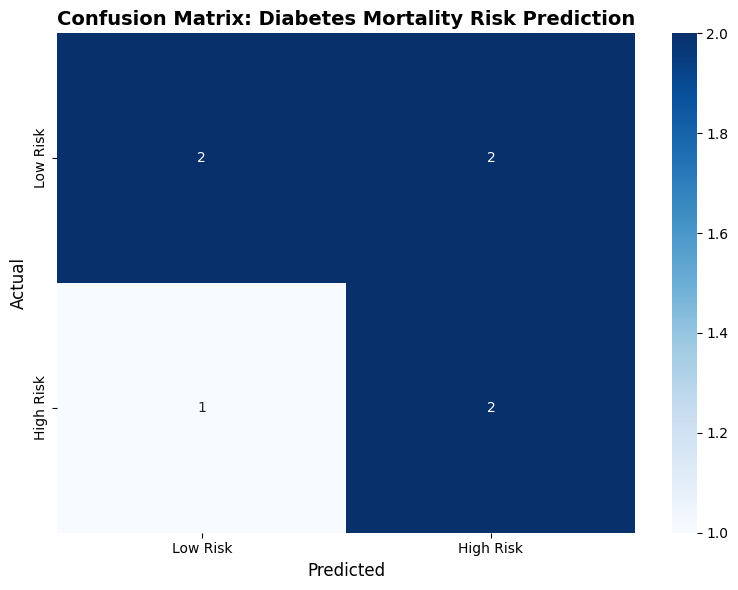

In [19]:
# ── CONFUSION MATRIX ──
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
plt.title('Confusion Matrix: Diabetes Mortality Risk Prediction', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

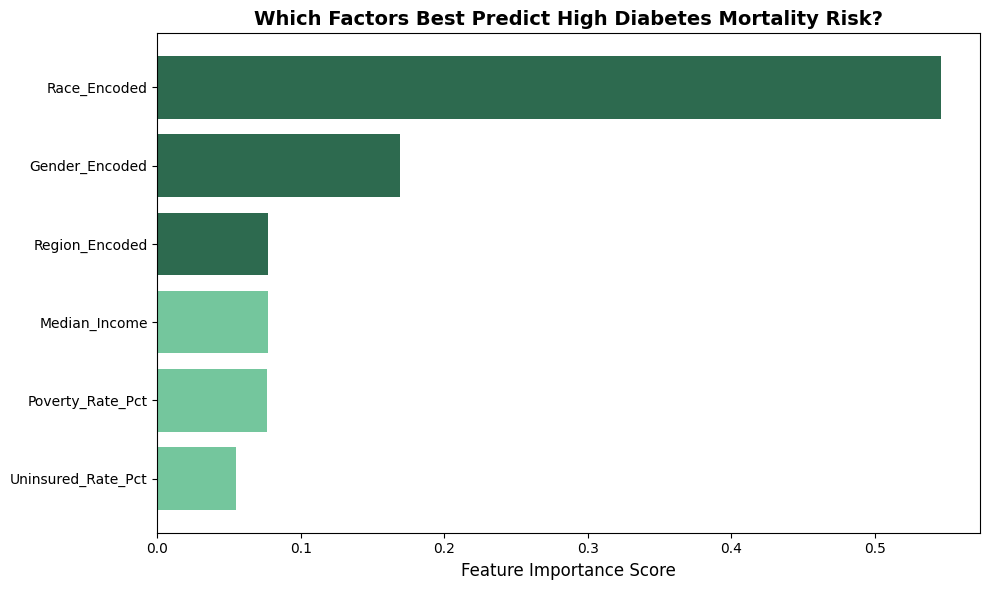


Feature Importance Rankings:
           Feature  Importance
      Race_Encoded    0.545959
    Gender_Encoded    0.169128
    Region_Encoded    0.077180
     Median_Income    0.076834
  Poverty_Rate_Pct    0.076066
Uninsured_Rate_Pct    0.054833


In [20]:
# ── FEATURE IMPORTANCE ──
importances = rf_clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#2d6a4f' if i < 3 else '#74c69d' for i in range(len(features))]
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color=colors)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Which Factors Best Predict High Diabetes Mortality Risk?', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\nFeature Importance Rankings:')
print(feature_importance_df.to_string(index=False))

### Answer to Motivating Question & Stakeholder Insights

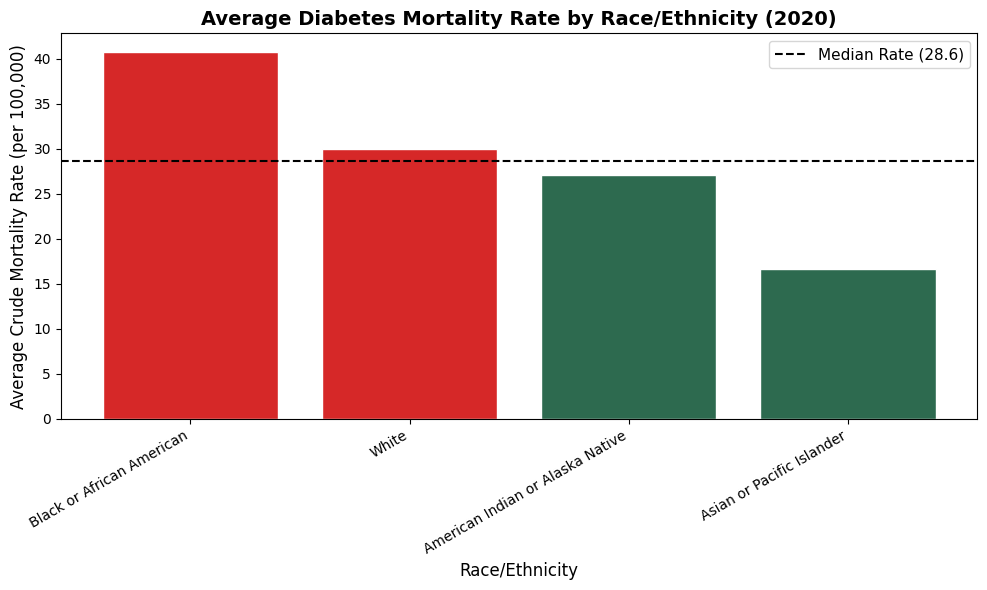

In [21]:
# ── MORTALITY RATE BY RACE — VISUALIZATION ──
race_mortality = merged_df.groupby(race_col)['Crude Rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_race = ['#d62828' if r > median_rate else '#2d6a4f' for r in race_mortality.values]
bars = plt.bar(race_mortality.index, race_mortality.values, color=colors_race, edgecolor='white')
plt.axhline(y=median_rate, color='black', linestyle='--', linewidth=1.5, label=f'Median Rate ({median_rate:.1f})')
plt.xlabel('Race/Ethnicity', fontsize=12)
plt.ylabel('Average Crude Mortality Rate (per 100,000)', fontsize=12)
plt.title('Average Diabetes Mortality Rate by Race/Ethnicity (2020)', fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

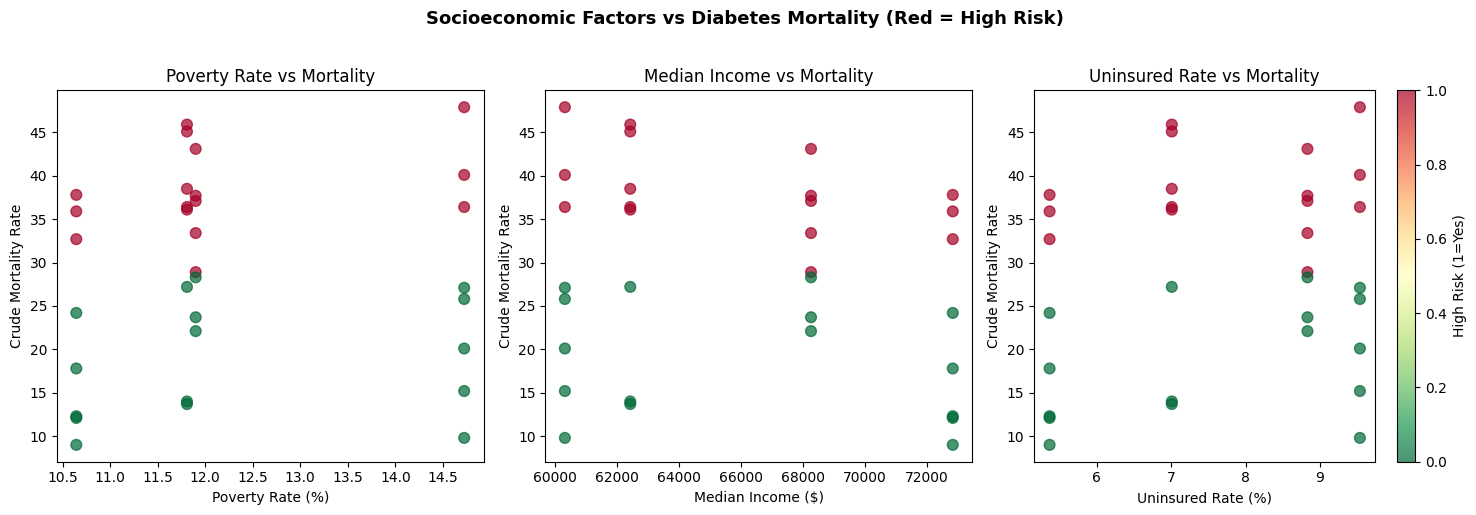

In [22]:
# ── SOCIOECONOMIC FACTORS vs MORTALITY RATE ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Poverty vs Mortality
axes[0].scatter(merged_df['Poverty_Rate_Pct'], merged_df['Crude Rate'],
                c=merged_df['High_Risk'], cmap='RdYlGn_r', alpha=0.7, s=60)
axes[0].set_xlabel('Poverty Rate (%)')
axes[0].set_ylabel('Crude Mortality Rate')
axes[0].set_title('Poverty Rate vs Mortality')

# Income vs Mortality
axes[1].scatter(merged_df['Median_Income'], merged_df['Crude Rate'],
                c=merged_df['High_Risk'], cmap='RdYlGn_r', alpha=0.7, s=60)
axes[1].set_xlabel('Median Income ($)')
axes[1].set_ylabel('Crude Mortality Rate')
axes[1].set_title('Median Income vs Mortality')

# Uninsured vs Mortality
sc = axes[2].scatter(merged_df['Uninsured_Rate_Pct'], merged_df['Crude Rate'],
                     c=merged_df['High_Risk'], cmap='RdYlGn_r', alpha=0.7, s=60)
axes[2].set_xlabel('Uninsured Rate (%)')
axes[2].set_ylabel('Crude Mortality Rate')
axes[2].set_title('Uninsured Rate vs Mortality')

plt.colorbar(sc, ax=axes[2], label='High Risk (1=Yes)')
plt.suptitle('Socioeconomic Factors vs Diabetes Mortality (Red = High Risk)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()